# **DCIS301 Curso disciplinar avanzado. Procesamiento de señales biomédicas**
## Profesor: David Ortiz
=========================================

---

**Recuerde los lineamientos indicados en la Guía detallada del curso presentada el primer día de clase. Algunos a resaltar:**

- Los quices se han eliminado, lo que implica que la nota del informe escrito será la nota final del informe.
- Respetar el número máximo de páginas estipuladas. Se descontarán 2 décimas por página adicional.
- El informe debe ser digitado en un editor de texto (Word, $\LaTeX$, Documentos de Google) y enviado en formato PDF. No se aceptarán informes escritos a mano.
- **Solo está permitido el uso de ChatGPT, y deberán incluir en el informe el link de la conversación (Chat) con el programa.**
- **Los códigos empleados deberán ser incluidos al final del informe escrito, y estos no sumarán al máximo número de páginas establecido.**
- Antes de la fecha y hora límite, el informe en formato PDF debe ser subido al *Aula Virtual*, en la pestaña correspondiente. Recuerden que la originalidad del informe será evaluada con la herramienta Turniting, y esto considera el correcto uso de ChatGPT.
- Se espera que las respuestas sean explícitas, detalladas y matemáticamente soportadas. Es fundamental utilizar la teoría vista en clase para sustentar los argumentos, incluyendo fórmulas, ecuaciones, transformaciones y cualquier otro recurso necesario para respaldar el razonamiento. La precisión y solidez de la fundamentación será un criterio clave en la evaluación.

---

*Se otorgará una bonificación de 0.3 puntos si el informe está redactado en inglés, y una bonificación adicional de 0.3 puntos si se utiliza* $\LaTeX$ *para su digitación. Para verificar este último criterio, se debe adjuntar el archivo* `.tex` *del informe en el mensaje de entrega.*

Funciones auxiliares para el desarrollo de la tarea 3 y 4:

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import (
    butter, find_peaks, spectrogram, 
    get_window, filtfilt, freqz
    )
from scipy.stats import entropy, kurtosis, skew

import pandas as pd
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def graficar_fourier(signal, fs, ax=None, only_magnitude=True, logarithmic=True):
    """
    Calcula y grafica la FFT. Si ax es None, crea figura nueva con magnitud y fase.
    Si ax es un eje matplotlib, grafica solo la magnitud en ese eje.
    
    Args:
        signal (np.ndarray): Señal de entrada.
        fs (float): Frecuencia de muestreo (Hz).
        ax (matplotlib.axes.Axes): Eje donde graficar la magnitud (opcional).
        only_magnitude (bool): Si True, solo grafica la magnitud.
    """
    Nsample = len(signal)
    yf = fft(signal)[:Nsample // 2]
    xf = fftfreq(Nsample, d=1/fs)[:Nsample // 2]  # Tomar solo frecuencias positivas
    
    magnitude = 2 * np.abs(yf) / Nsample
    if logarithmic:
        # Convertir a escala logarítmica
        magnitude = 10 * np.log10(magnitude + 1e-10)
    phase = np.angle(yf)

    # Eliminar componentes cercanas a cero en la fase
    threshold = 1e-6  # Umbral para eliminar componentes pequeñas
    phase[np.abs(magnitude) < threshold] = 0  # Asignar fase cero donde la magnitud es pequeña

    if ax is None:
        # Gráfica normal: magnitud y fase en figura nueva
        plt.figure(figsize=(8, 6))
        # Magnitud
        ax1 = plt.subplot(2, 1, 1)
        ax1.plot(xf, magnitude, color='b')
        ax1.set_xlabel(r"Frecuencia [Hz]", size=16)
        ax1.set_ylabel(r"$|X(f)|$", size=16)
        ax1.set_title(f'Espectro de Fourier de la señal', size=16)
        ax1.grid(True)
        # Fase (opcional)
        if not only_magnitude:
            ax2 = plt.subplot(2, 1, 2)
            ax2.plot(xf, phase, color='b')
            ax2.set_xlabel("Frecuencia [Hz]", size=16)
            ax2.set_ylabel(r"$\phi(f)$", size=16)
            ax2.set_title("Fase", size=16)
            ax2.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        # Graficar solo magnitud en axes dado
        ax.plot(xf, magnitude, color='b')
        ax.set_xlabel(r"Frecuencia [Hz]", size=14)
        ax.set_ylabel(r"$|X(f)|$", size=14)
        ax.set_title(f'FFT Magnitud', size=14)
        ax.grid(True)


def plot_spectrogram(signal, sample_rate, overlapping = 0.5, window_type='hann', window_size=256, ax = None):
    """
    Genera y grafica el espectrograma de una señal.

    Parámetros:
    - signal: la señal de audio
    - window_type: el tipo de ventana a usar (string, por ejemplo 'hann', 'hamming', etc.)
    - window_size: tamaño de la ventana (entero)
    - overlapping: porcentaje de solapamiento (valor entre 0 y 1)
    - fs: frecuencia de muestreo de la señal
    """
    # Crear la ventana
    window = get_window(window_type, window_size)

    # Calcular el paso de la ventana en función del solapamiento
    noverlap = int(overlapping * window_size)

    # Calcular el espectrograma usando scipy.signal.spectrogram
    f, t, Sxx = spectrogram(signal, fs=sample_rate, window=window,
                            nperseg=window_size, noverlap=noverlap)

    if ax is None:
        # Graficar el espectrograma
        plt.figure(figsize=(5, 3))
        plt.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
        plt.title('Espectrograma')
        plt.xlabel('Tiempo [s]')
        plt.colorbar(label='Amplitud [dB]')
        plt.show()
    else:
        # Graficar en el eje dado
        ax.pcolormesh(t, f, 10 * np.log10(Sxx), shading='gouraud')
        ax.set_title('Espectrograma')
        ax.set_ylabel('Frecuencia [Hz]')
        ax.set_xlabel('Tiempo [s]')
        ax.colorbar(label='Amplitud [dB]')
        ax.grid(True)
    
def normalize_zscore(signal):
    """
    Estandarización Z-score: Media 0 y Desviación Estándar 1.
    Ideal para preservar la varianza y mitigar el efecto de valores atípicos.
    """
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    
    if std_val == 0:
        return signal - mean_val
        
    return (signal - mean_val) / std_val

def normalize_minmax_symmetric(signal):
    """
    Escalado Min-Max al rango [-1, 1].
    Útil cuando los algoritmos requieren límites estrictos, 
    pero muy sensible a valores atípicos.
    """
    min_val = np.min(signal)
    max_val = np.max(signal)
    
    if max_val == min_val:
        return np.zeros_like(signal)
        
    # Primero se escala a [0, 1] y luego se transforma a [-1, 1]
    norm_01 = (signal - min_val) / (max_val - min_val)
    return 2 * norm_01 - 1


def compute_stat_metrics(signal, sample_rate, window_size=128, overlap=0.0, window_type='boxcar', hist_bins=10):
    """
    Calcula métricas estadísticas sobre ventanas solapadas de una señal 1D.
    
    Args:
        signal (ndarray): Señal de entrada.
        sample_rate (float): Frecuencia de muestreo (Hz).
        window_size (int): Tamaño de la ventana en muestras.
        overlap (float): Fracción de solapamiento [0,1).
        window_type (str): Tipo de ventana (e.g., 'boxcar', 'hann').
        hist_bins (int): Número de bins para el cálculo de entropía.
    
    Returns:
        dict: Contiene 'times' y un diccionario con listas de métricas.
    """
    t = np.linspace(0, len(signal)/sample_rate, len(signal), endpoint=False)
    step = int(window_size * (1 - overlap))
    win = get_window(window_type, window_size)
    
    times = []
    metrics = {k: [] for k in ['mean','variance','median','max','min','range','shannon_entropy','kurtosis','skewness']}
    
    for start in range(0, len(signal) - window_size + 1, step):
        segment = signal[start:start + window_size] * win
        times.append(t[start + window_size - 1])
        
        metrics['mean'].append(np.mean(segment))
        metrics['variance'].append(np.var(segment))
        metrics['median'].append(np.median(segment))
        metrics['max'].append(np.max(segment))
        metrics['min'].append(np.min(segment))
        metrics['range'].append(np.max(segment) - np.min(segment))
        
        hist, _ = np.histogram(segment, bins=hist_bins, density=True)
        metrics['shannon_entropy'].append(entropy(hist + 1e-12, base=2))
        metrics['kurtosis'].append(kurtosis(segment))
        metrics['skewness'].append(skew(segment))
    
    return times, metrics

def compute_dynamic_metrics(signal, sample_rate, window_size=128, overlap=0.5, window_type='boxcar'):
    """
    Calcula métricas dinámicas sobre ventanas solapadas de una señal 1D.
    
    Args:
        signal (ndarray): Señal de entrada.
        sample_rate (float): Frecuencia de muestreo (Hz).
        window_size (int): Tamaño de ventana en muestras.
        overlap (float): Fracción de solapamiento [0,1).
        window_type (str): Tipo de ventana (e.g., 'boxcar', 'hann').
    
    Returns:
        dict: Contiene 'times' y un diccionario con listas de métricas dinámicas.
    """
    t = np.linspace(0, len(signal)/sample_rate, len(signal), endpoint=False)
    step = int(window_size * (1 - overlap))
    win = get_window(window_type, window_size)
    
    times = []
    metrics_dyn = {k: [] for k in ['zcr','zcr_var','slope','velocity','acceleration','peak_count','energy','power']}
    
    for start in range(0, len(signal) - window_size + 1, step):
        segment = signal[start:start + window_size] * win
        times.append(t[start])
        
        # Cruces por cero
        zero_crossings = np.where(np.diff(np.sign(segment)) != 0)[0]
        metrics_dyn['zcr'].append(len(zero_crossings))
        metrics_dyn['zcr_var'].append(np.var(np.diff(zero_crossings)) if len(zero_crossings) > 1 else 0)
        
        # Derivadas
        diff1 = np.diff(segment)
        diff2 = np.diff(diff1)
        metrics_dyn['slope'].append(np.mean(diff1))
        metrics_dyn['velocity'].append(np.mean(np.abs(diff1)))
        metrics_dyn['acceleration'].append(np.mean(np.abs(diff2)))
        
        # Picos
        peaks, _ = find_peaks(segment)
        metrics_dyn['peak_count'].append(len(peaks))
        
        # Energía y potencia
        energy = np.sum(segment**2)
        metrics_dyn['energy'].append(energy)
        metrics_dyn['power'].append(energy / window_size)
    
    return times, metrics_dyn


def tsne_simple(señal1, señal2, fs=360, window_type = 'boxcar', window_size=128, overlap=0.5, perplexity=30, plot=True):
    """
    t-SNE simple para dos señales (reposo y sueño) usando métricas por ventanas.
    Requiere tener definidas: compute_windowed_metrics y compute_dynamic_metrics.
    """
    # Reposo
    m_r = {**compute_stat_metrics(señal1, fs,  window_size, overlap, window_type)[1],
           **compute_dynamic_metrics(señal1, fs,  window_size, overlap, window_type)[1]}
    df_r = pd.DataFrame(m_r); df_r['cond'] = 'señal1'
    # Sueño
    m_s = {**compute_stat_metrics(señal2, fs, window_size, overlap, window_type)[1],
           **compute_dynamic_metrics(señal2, fs, window_size, overlap, window_type)[1]}
    df_s = pd.DataFrame(m_s); df_s['cond'] = 'señal2'

    df = pd.concat([df_r, df_s], ignore_index=True)
    labels = df['cond'].to_numpy()
    X = df.drop(columns=['cond']).to_numpy()

    X_scaled = StandardScaler().fit_transform(X)
    X_tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42).fit_transform(X_scaled)

    if plot:
        plt.figure(figsize=(5.2, 4.5))
        for c, name in [('señal1', 'Señal 1'), ('señal2', 'Señal 2')]:
            idx = labels == c
            plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=32, alpha=0.8, edgecolor='k', label=name)
        plt.title("t-SNE de métricas por ventana — Señal 1 vs. Señal 2")
        plt.xlabel("Comp. 1"); plt.ylabel("Comp. 2"); plt.legend(); plt.grid(True, ls='--', alpha=0.3)
        plt.tight_layout(); plt.show()

    return {"embedding": X_tsne, "labels": labels, "features": df}


## **EEG During Mental Arithmetic Tasks**
Base de datos PhysioNet — EEG registrado durante tareas de sustracción serial (aritmética mental).
- **Grupo G** (Count quality = 1): buenos ejecutores → **grupo control**
- **Grupo B** (Count quality = 0): malos ejecutores → **grupo patológico**
- Sujetos representativos: **Subject01** (G/control) vs **Subject00** (B/patológico)
- Archivos utilizados: `subjectXX_2.edf` (EEG durante la tarea aritmética)
- Formato: EDF, 21 canales, fs = 500 Hz, ~60 s por registro (preprocesamiento ICA ya aplicado)

Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345. DOI (version 1.0.0): 10.13026/C2JQ1P 


=== Sujetos disponibles ===
  Subject  Count quality            Group
Subject00              0 B (pathological)
Subject01              1      G (control)
Subject03              1      G (control)
Subject06              0 B (pathological)

Canales disponibles: ['EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG T3', 'EEG T4', 'EEG C3', 'EEG C4', 'EEG T5', 'EEG T6', 'EEG P3', 'EEG P4', 'EEG O1', 'EEG O2', 'EEG Fz', 'EEG Cz', 'EEG Pz', 'EEG A2-A1', 'ECG ECG']
Canal seleccionado: EEG Fz  |  fs = 500 Hz

=== Resumen de señales ===
  Subject00 [B (pathological)]: fs=500 Hz | muestras=31000 | duración=62.0s | canal=EEG Fz
  Subject01 [G (control)]: fs=500 Hz | muestras=31000 | duración=62.0s | canal=EEG Fz

Segmento: 5000–15000 muestras  (10s – 30s)


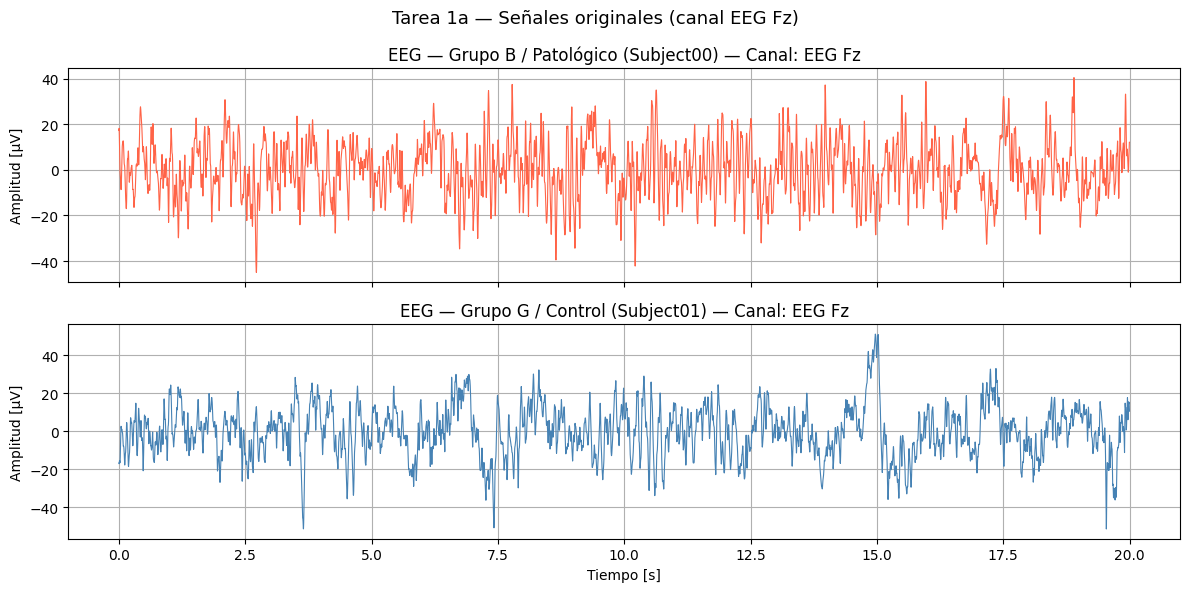

In [16]:
import pyedflib
import pandas as pd
import os

DATA_DIR = 'data'

# --- 1a) Leer metadata y filtrar los 4 sujetos disponibles ---
info = pd.read_csv(f'{DATA_DIR}/subject-info.csv')
subjects_used = ['Subject00', 'Subject01', 'Subject03', 'Subject06']
info_subset = info[info['Subject'].isin(subjects_used)][['Subject', 'Count quality']].copy()
info_subset['Group'] = info_subset['Count quality'].map({1: 'G (control)', 0: 'B (pathological)'})
print("=== Sujetos disponibles ===")
print(info_subset.to_string(index=False))

# --- Función auxiliar para cargar un canal de un EDF ---
def load_edf_channel(filepath, channel_name):
    with pyedflib.EdfReader(filepath) as f:
        labels = f.getSignalLabels()
        fs     = int(f.getSampleFrequency(0))
        idx    = labels.index(channel_name)
        signal = f.readSignal(idx)
    return signal, fs

# --- Cargar Subject00 (B/patológico) y Subject01 (G/control) ---
CHANNEL = 'EEG Fz'   # canal frontal midline — asociado a carga cognitiva

eeg_bad,  fs = load_edf_channel(f'{DATA_DIR}/Subject00_2.edf', CHANNEL)
eeg_good, _  = load_edf_channel(f'{DATA_DIR}/Subject01_2.edf', CHANNEL)

# --- Mostrar canales disponibles ---
with pyedflib.EdfReader(f'{DATA_DIR}/Subject00_2.edf') as f:
    print(f"\nCanales disponibles: {f.getSignalLabels()}")
print(f"Canal seleccionado: {CHANNEL}  |  fs = {fs} Hz")

# --- Resumen ---
print("\n=== Resumen de señales ===")
for subj, grp, sig in [('Subject00', 'B (pathological)', eeg_bad),
                        ('Subject01', 'G (control)',      eeg_good)]:
    print(f"  {subj} [{grp}]: fs={fs} Hz | muestras={len(sig)} | "
          f"duración={len(sig)/fs:.1f}s | canal={CHANNEL}")

# --- Segmento de 20 s (desde segundo 10) ---
seg_start = 10 * fs
seg_end   = seg_start + 20 * fs

eeg_bad_seg  = eeg_bad[seg_start:seg_end]
eeg_good_seg = eeg_good[seg_start:seg_end]

t = np.arange(len(eeg_bad_seg)) / fs   # eje de tiempo [s]

print(f"\nSegmento: {seg_start}–{seg_end} muestras  "
      f"({seg_start/fs:.0f}s – {seg_end/fs:.0f}s)")

# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, eeg_bad_seg,  color='tomato',   lw=0.8)
axes[0].set_title('EEG — Grupo B / Patológico (Subject00) — Canal: ' + CHANNEL)
axes[0].set_ylabel('Amplitud [µV]')
axes[0].grid(True)

axes[1].plot(t, eeg_good_seg, color='steelblue', lw=0.8)
axes[1].set_title('EEG — Grupo G / Control (Subject01) — Canal: ' + CHANNEL)
axes[1].set_ylabel('Amplitud [µV]')
axes[1].set_xlabel('Tiempo [s]')
axes[1].grid(True)

plt.suptitle('Tarea 1a — Señales originales (canal EEG Fz)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_1a_original.png', dpi=150, bbox_inches='tight')
plt.show()

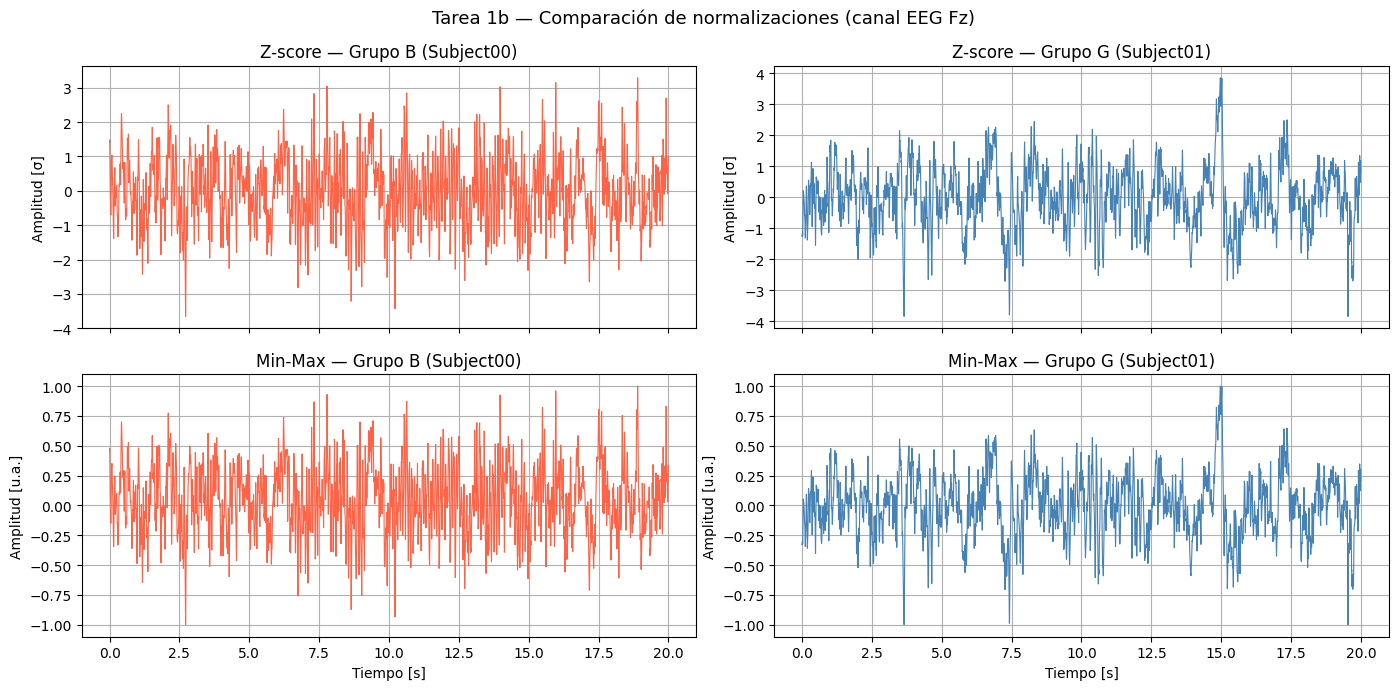

In [13]:
# --- 1b) Comparación de normalizaciones: Z-score y Min-Max ---

# Normalizar ambas señales con cada método
bad_zscore  = normalize_zscore(eeg_bad_seg)
good_zscore = normalize_zscore(eeg_good_seg)
bad_minmax  = normalize_minmax_symmetric(eeg_bad_seg)
good_minmax = normalize_minmax_symmetric(eeg_good_seg)

# Layout: 2 filas × 2 columnas
# Fila 1 → Z-score | Fila 2 → Min-Max
# Columna 1 → Grupo B (patológico) | Columna 2 → Grupo G (control)
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)

# --- Fila 1: Z-score ---
axes[0, 0].plot(t, bad_zscore,  color='tomato',   lw=0.8)
axes[0, 0].set_title('Z-score — Grupo B (Subject00)')
axes[0, 0].set_ylabel('Amplitud [σ]')
axes[0, 0].grid(True)

axes[0, 1].plot(t, good_zscore, color='steelblue', lw=0.8)
axes[0, 1].set_title('Z-score — Grupo G (Subject01)')
axes[0, 1].set_ylabel('Amplitud [σ]')
axes[0, 1].grid(True)

# --- Fila 2: Min-Max simétrico [-1, 1] ---
axes[1, 0].plot(t, bad_minmax,  color='tomato',   lw=0.8)
axes[1, 0].set_title('Min-Max — Grupo B (Subject00)')
axes[1, 0].set_ylabel('Amplitud [u.a.]')
axes[1, 0].set_xlabel('Tiempo [s]')
axes[1, 0].grid(True)

axes[1, 1].plot(t, good_minmax, color='steelblue', lw=0.8)
axes[1, 1].set_title('Min-Max — Grupo G (Subject01)')
axes[1, 1].set_ylabel('Amplitud [u.a.]')
axes[1, 1].set_xlabel('Tiempo [s]')
axes[1, 1].grid(True)

plt.suptitle('Tarea 1b — Comparación de normalizaciones (canal EEG Fz)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_1b_normalizacion.png', dpi=150, bbox_inches='tight')
plt.show()

  Análisis de Nyquist — EEG Fz (EDF, 500 Hz)
  fs                      = 500 Hz
  f_Nyquist  (fs / 2)     = 250.0 Hz
  fmax clínico (EEG)      = 100 Hz  (gamma alta)
  Condición fs > 2·fmax   : CUMPLE
  Factor de sobremuestreo = 2.5x
  Muestras en segmento    = 10000  (20 s × 500 Hz)
  Memoria (2 señales)     ≈ 156.2 KB


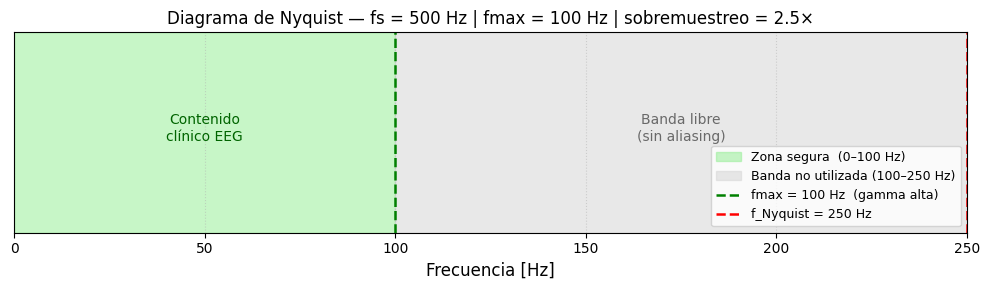

Figura guardada: fig_1c_nyquist.png


In [20]:
# --- 1c) Análisis de Nyquist ---

fmax       = 100        # Hz — gamma alta: límite clínico relevante del EEG
f_nyquist  = fs / 2     # frecuencia de Nyquist del sistema de adquisición
cumple     = fs > 2 * fmax
factor_os  = fs / (2 * fmax)
n_muestras = len(eeg_bad_seg)
memoria_kb = (n_muestras * 2 * 8) / 1024   # 2 señales × float64 (8 bytes)

print("=" * 50)
print("  Análisis de Nyquist — EEG Fz (EDF, 500 Hz)")
print("=" * 50)
print(f"  fs                      = {fs} Hz")
print(f"  f_Nyquist  (fs / 2)     = {f_nyquist:.1f} Hz")
print(f"  fmax clínico (EEG)      = {fmax} Hz  (gamma alta)")
print(f"  Condición fs > 2·fmax   : {'CUMPLE' if cumple else 'NO CUMPLE'}")
print(f"  Factor de sobremuestreo = {factor_os:.1f}x")
print(f"  Muestras en segmento    = {n_muestras}  (20 s × {fs} Hz)")
print(f"  Memoria (2 señales)     ≈ {memoria_kb:.1f} KB")
print("=" * 50)

# --- Diagrama del eje de frecuencias ---
fig, ax = plt.subplots(figsize=(10, 3))

# Zona segura: contenido clínico del EEG (0 – fmax)
ax.axvspan(0,    fmax,      color='lightgreen', alpha=0.5, label=f'Zona segura  (0–{fmax} Hz)')
# Banda sin información clínica (fmax – f_Nyquist)
ax.axvspan(fmax, f_nyquist, color='lightgray',  alpha=0.5, label=f'Banda no utilizada ({fmax}–{f_nyquist:.0f} Hz)')

# Líneas de referencia
ax.axvline(fmax,      color='green', linestyle='--', lw=1.8, label=f'fmax = {fmax} Hz  (gamma alta)')
ax.axvline(f_nyquist, color='red',   linestyle='--', lw=1.8, label=f'f_Nyquist = {f_nyquist:.0f} Hz')

# Anotaciones de texto en coordenadas de ejes (y relativo 0–1)
ax.text(fmax / 2,             0.52, 'Contenido\nclínico EEG',
        ha='center', va='center', fontsize=10, color='darkgreen',
        transform=ax.get_xaxis_transform())
ax.text((fmax + f_nyquist)/2, 0.52, 'Banda libre\n(sin aliasing)',
        ha='center', va='center', fontsize=10, color='dimgray',
        transform=ax.get_xaxis_transform())

ax.set_xlim(0, f_nyquist)
ax.set_ylim(0, 1)
ax.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax.set_yticks([])
ax.set_title(
    f'Diagrama de Nyquist — fs = {fs} Hz | fmax = {fmax} Hz | '
    f'sobremuestreo = {factor_os:.1f}×',
    fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('fig_1c_nyquist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_1c_nyquist.png")

In [ ]:
# --- 1d) Transformada de Fourier en dB con bandas EEG ---

# Bandas clínicas del EEG: (nombre, f_inicio, f_fin, color)
bandas = [
    ('Delta',  0,   4,   'mediumpurple'),
    ('Theta',  4,   8,   'cornflowerblue'),
    ('Alpha',  8,   13,  'mediumseagreen'),
    ('Beta',   13,  30,  'gold'),
    ('Gamma',  30,  100, 'salmon'),
]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Función auxiliar para sombrear bandas en un eje ---
def sombrear_bandas(ax):
    for nombre, f0, f1, color in bandas:
        ax.axvspan(f0, f1, color=color, alpha=0.18, label=nombre)
        ax.text((f0 + f1) / 2, 0.97, nombre,
                ha='center', va='top', fontsize=7.5, color='black',
                transform=ax.get_xaxis_transform())

# --- Fila 1: Grupo B (patológico) ---
graficar_fourier(bad_zscore, fs, ax=axes[0], only_magnitude=True, logarithmic=True)
sombrear_bandas(axes[0])
axes[0].set_xlim(0, 100)        # rango clínico del EEG
axes[0].set_title('FFT (dB) — Grupo B / Patológico (Subject00) — EEG Fz Z-score')
axes[0].set_ylabel('Magnitud [dB]')
axes[0].lines[0].set_color('tomato')   # recolorear la línea trazada por graficar_fourier
axes[0].legend(loc='upper right', fontsize=8, ncol=5)

# --- Fila 2: Grupo G (control) ---
graficar_fourier(good_zscore, fs, ax=axes[1], only_magnitude=True, logarithmic=True)
sombrear_bandas(axes[1])
axes[1].set_xlim(0, 100)
axes[1].set_title('FFT (dB) — Grupo G / Control (Subject01) — EEG Fz Z-score')
axes[1].set_ylabel('Magnitud [dB]')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].lines[0].set_color('steelblue')
axes[1].legend(loc='upper right', fontsize=8, ncol=5)

plt.suptitle('Tarea 1d — Espectro de Fourier en dB con bandas EEG (canal Fz)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_1d_fourier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_1d_fourier.png")

In [ ]:
# --- 1d v2) FFT en dB (escala de amplitud: 20·log10) con diagnóstico y bandas EEG ---
# Se calcula manualmente con rfft para usar 20·log10 (amplitud), no 10·log10 (potencia)
from scipy.fft import rfft, rfftfreq

def calcular_fft_db(signal, fs):
    """Retorna (freqs, magnitud_db) usando escala de amplitud: 20·log10."""
    N           = len(signal)
    freqs       = rfftfreq(N, d=1/fs)
    magnitude   = (2 / N) * np.abs(rfft(signal))
    magnitude_db = 20 * np.log10(magnitude + 1e-10)
    return freqs, magnitude_db

def diagnostico_espectral(freqs, mag_db, label):
    """Imprime pico dominante y detecta posible filtro previo en 25–35 Hz."""
    # Pico máximo dentro del rango clínico (0–100 Hz)
    mascara_clinica = freqs <= 100
    idx_pico = np.argmax(mag_db[mascara_clinica])
    f_pico   = freqs[mascara_clinica][idx_pico]
    v_pico   = mag_db[mascara_clinica][idx_pico]

    # Detección de caída abrupta entre 25–35 Hz respecto a media de 15–25 Hz
    media_ref  = np.mean(mag_db[(freqs >= 15) & (freqs <= 25)])
    vals_caida = mag_db[(freqs >= 25) & (freqs <= 35)]
    caida_max  = media_ref - np.min(vals_caida)   # mayor descenso detectado

    print(f"\n  [{label}]")
    print(f"    Pico dominante : {v_pico:.1f} dB  @  {f_pico:.2f} Hz")
    print(f"    Media 15–25 Hz : {media_ref:.1f} dB")
    print(f"    Caída max 25–35 Hz : {caida_max:.1f} dB", end="  ")
    if caida_max > 15:
        print("⚠ Posible filtro previo detectado")
    else:
        print("— sin caída significativa")

# --- Calcular espectros ---
freqs_bad,  mag_db_bad  = calcular_fft_db(bad_zscore,  fs)
freqs_good, mag_db_good = calcular_fft_db(good_zscore, fs)

print("=" * 52)
print("  Diagnóstico espectral — 1d v2")
print("=" * 52)
diagnostico_espectral(freqs_bad,  mag_db_bad,  "Subject00 — Grupo B (patológico)")
diagnostico_espectral(freqs_good, mag_db_good, "Subject01 — Grupo G (control)")
print("=" * 52)

# --- Graficar ---
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Máscara para limitar el eje x al rango clínico
mask_bad  = freqs_bad  <= 100
mask_good = freqs_good <= 100

# Fila 1 — Grupo B (patológico)
axes[0].plot(freqs_bad[mask_bad],   mag_db_bad[mask_bad],   color='tomato',   lw=0.9)
axes[0].set_title('FFT (dB, 20·log₁₀) — Grupo B / Patológico (Subject00) — EEG Fz Z-score')
axes[0].set_ylabel('Magnitud [dB]')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Fila 2 — Grupo G (control)
axes[1].plot(freqs_good[mask_good], mag_db_good[mask_good], color='steelblue', lw=0.9)
axes[1].set_title('FFT (dB, 20·log₁₀) — Grupo G / Control (Subject01) — EEG Fz Z-score')
axes[1].set_ylabel('Magnitud [dB]')
axes[1].set_xlabel('Frecuencia [Hz]')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Sombrear bandas EEG en ambos ejes
for ax in axes:
    sombrear_bandas(ax)
    ax.set_xlim(0, 100)
    ax.legend(loc='upper right', fontsize=8, ncol=5)

plt.suptitle('Tarea 1d — Espectro de Fourier en dB (amplitud) con bandas EEG (canal Fz)',
             fontsize=13)
plt.tight_layout()
plt.savefig('fig_1d_fourier_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada: fig_1d_fourier_v2.png")